# Phần 1 — Bài toán tổ hợp

Dạng **Assignment / Labeling**: gán giá trị rời rạc cho một tập biến, ràng buộc chủ
đạo là ràng buộc phân biệt (`allDifferent`, `!=`). Thường là CSP thuần — chỉ cần
tìm một cấu hình khả thi.

Hai bài trong phần này cùng dạng nhưng cho **hai kết quả trái ngược** ở trục so
sánh ngôn ngữ, và đó chính là chỗ đáng đọc:

| Bài | Chênh lệch OPL vs DOcplex.cp (cùng engine) |
|---|---|
| 1.1 Tô màu đồ thị | đúng **1** nhánh |
| 1.2 N-Queens | **73 %** |

Nguyên nhân của sự khác biệt đó được phân tích ở mục (d) của từng bài.

In [1]:
import sys; sys.path.insert(0, "../tools")
from nbutil import *
from nbviz import *

---

# Bài 1.1 — Tô màu đồ thị (Graph Coloring)

## (a) Phát biểu bài toán

In [2]:
show_notes("1.1_graph_coloring", "Phát biểu")

## (a) Phát biểu bài toán

Cho một bản đồ gồm nhiều vùng và một bảng màu có $K$ màu. Hãy tô màu cho **mọi
vùng** sao cho **không có hai vùng chung biên giới nào cùng màu**.

Trừu tượng hoá thành đồ thị: mỗi vùng là một **đỉnh**, mỗi cặp vùng có chung biên
giới là một **cạnh**. Bài toán trở thành *tô màu đỉnh của đồ thị*: gán cho mỗi đỉnh
một trong $K$ màu sao cho hai đầu của mọi cạnh khác màu nhau.

| | Nội dung |
|---|---|
| **Dữ liệu vào** | đồ thị vô hướng $G=(V,E)$; số màu cho phép $K$; danh sách tên màu |
| **Dữ liệu ra** | một ánh xạ *đỉnh → màu*, tức một phép tô hợp lệ |
| **Ràng buộc** | hai đỉnh kề nhau không được cùng màu |
| **Mục tiêu** | không có — đây là **CSP thuần**: chỉ cần tìm một nghiệm khả thi |

Bộ dữ liệu dùng chung cho cả ba chiều là **đúng bộ của hai ví dụ chính thức**
(`color.mod` của OPL và `examples/cp/basic/color.py` của DOcplex.cp): bản đồ 6
nước Tây Âu với 9 đường biên giới, và bảng 4 màu.

| | Giá trị |
|---|---|
| $V$ | Belgium, Denmark, France, Germany, Luxembourg, Netherlands — $\lvert V\rvert=6$ |
| $E$ | BE–FR, BE–DE, BE–NL, BE–LU, DK–DE, FR–DE, FR–LU, DE–LU, DE–NL — $\lvert E\rvert=9$ |
| $K$ | 4 — blue, white, yellow, green |

File dữ liệu: [`data/coloring/map6.dat`](../../data/coloring/map6.dat).

**Phần mở rộng (tuỳ chọn, cờ `--min`):** biến bài toán thoả mãn ràng buộc thành
bài toán tối ưu — *ít nhất bao nhiêu màu là đủ để tô được $G$?* Đại lượng đó là
**sắc số** $\chi(G)$.

---

## (b) Mô hình toán học

Mô hình dưới đây là **hợp đồng chung** mà cả ba chiều cùng cài đặt. Ba đoạn code ở mục (c) chỉ là ba cách diễn đạt đúng mô hình này.

In [3]:
show_notes("1.1_graph_coloring", "Mô hình toán")

## (b) Mô hình toán học — dùng chung cho cả ba chiều

### Tập hợp

| Ký hiệu | Ý nghĩa |
|---|---|
| $V$ | tập đỉnh (vùng cần tô màu) |
| $E\subseteq\bigl\{\{u,v\}: u,v\in V,\ u\neq v\bigr\}$ | tập cạnh — mỗi cạnh là một cặp vùng chung biên giới |
| $\mathcal{K}=\{0,1,\dots,K-1\}$ | tập **nhãn màu** |

Đồ thị vô hướng nên mỗi cạnh chỉ ghi **một lần** trong dữ liệu; ràng buộc sinh ra
từ nó đối xứng theo hai đầu nên không cần ghi cả hai chiều.

### Tham số

| Ký hiệu | Kiểu | Ý nghĩa | Giá trị ở bộ dữ liệu này |
|---|---|---|---|
| $K$ | $\mathbb{Z}_{>0}$ | số màu được phép dùng | $4$ |
| $n=\lvert V\rvert$ | $\mathbb{Z}_{>0}$ | số đỉnh | $6$ |
| $m=\lvert E\rvert$ | $\mathbb{Z}_{\ge 0}$ | số cạnh | $9$ |
| $\mathrm{name}_k$ | chuỗi | tên hiển thị của màu $k\in\mathcal{K}$ | blue, white, yellow, green |

Màu chỉ là **nhãn**: $\mathrm{name}_k$ không tham gia vào mô hình, nó chỉ dùng lúc
in nghiệm. Đây là chỗ sinh ra đối xứng hoán vị màu, bàn ở cuối mục này.

### Biến quyết định

| Biến | Miền | Ý nghĩa |
|---|---|---|
| $x_v$ | $\mathcal{K}=\{0,\dots,K-1\}$ | nhãn màu gán cho đỉnh $v\in V$ |
| $\kappa$ | $\{1,\dots,K\}$ | *(chỉ ở phần mở rộng)* số màu thực sự được dùng |

Cả mô hình chỉ có $n$ biến. Ràng buộc "**mỗi vùng được tô đúng một màu**" —
thường phải viết thành ràng buộc riêng — ở đây **không tồn tại**: nó đã nằm sẵn
trong cách mã hoá, vì $x_v$ là một biến đơn trị nên tự động nhận đúng một giá trị.
Đây là nét đặc trưng của CP đã gặp ở bài 1.2 (biến $q_i$ nuốt luôn ràng buộc "mỗi
hàng một hậu"): **chọn cách mã hoá tốt thì một phần ràng buộc tự biến mất.**

**Đối chiếu với mã hoá nhị phân kiểu MILP.** Cách viết quen thuộc của quy hoạch
nguyên là $y_{v,k}\in\{0,1\}$ ("đỉnh $v$ mang màu $k$"), và khi đó phải thêm
$\sum_{k\in\mathcal{K}} y_{v,k}=1\ \forall v$ cùng $y_{u,k}+y_{v,k}\le 1\ \forall\{u,v\}\in E,\forall k$.

| | biến | ràng buộc | không gian tìm kiếm |
|---|---|---|---|
| CP — biến miền $\mathcal{K}$ | $n=6$ | $m=9$ | $K^{n}=4^6=4\,096$ ($\log_2 = 12$) |
| MILP — biến nhị phân | $nK=24$ | $n+mK=42$ | $2^{24}$ ($\log_2 = 24$) |

Cùng một bài toán, mã hoá biến nguyên cho không gian tìm kiếm nhỏ hơn hẳn. Với
bài 6 đỉnh thì chênh lệch này vô nghĩa, nhưng nó chính là lý do PLAN.md §2.1 chốt
**bỏ mã hoá nhị phân** ở bài 3.2 để lọt trần $2^{1000}$ của Community Edition.
Ở bài này $\log_2$ không gian tìm kiếm chỉ là **12** — cách trần 1000 rất xa.

### Ràng buộc

**(C1) Hai đỉnh kề nhau khác màu.** Đây là toàn bộ nội dung của bài toán:

$$x_u \neq x_v \qquad \forall\,\{u,v\}\in E \tag{C1}$$

Với bộ dữ liệu 6 nước, (C1) bung ra đúng 9 ràng buộc — cũng đúng 9 dòng `!=` mà hai
ví dụ chính thức của IBM viết tay:

$$
\begin{aligned}
&x_{\text{BE}}\neq x_{\text{FR}}, \quad
 x_{\text{BE}}\neq x_{\text{DE}}, \quad
 x_{\text{BE}}\neq x_{\text{NL}}, \quad
 x_{\text{BE}}\neq x_{\text{LU}}, \quad
 x_{\text{DK}}\neq x_{\text{DE}},\\[2pt]
&x_{\text{FR}}\neq x_{\text{DE}}, \quad
 x_{\text{FR}}\neq x_{\text{LU}}, \quad
 x_{\text{DE}}\neq x_{\text{LU}}, \quad
 x_{\text{DE}}\neq x_{\text{NL}}.
\end{aligned}
$$

**(C1′) Dạng mạnh hơn — `allDifferent` trên mỗi clique.** Nếu $Q\subseteq V$ là một
**clique** (mọi cặp đỉnh trong $Q$ đều kề nhau) thì $K$ ràng buộc $\neq$ rời rạc
tương đương với một ràng buộc toàn cục:

$$\texttt{allDifferent}\bigl(\{x_v : v\in Q\}\bigr) \qquad \forall\,Q\in\mathcal{Q} \tag{C1′}$$

với $\mathcal{Q}$ là một họ clique phủ hết các cạnh. (C1′) **cùng tập nghiệm** với
(C1) nhưng **lan truyền mạnh hơn**: bộ lọc của `allDifferent` dùng ghép cặp cực đại
trên đồ thị hai phía biến–giá trị, phát hiện được mâu thuẫn mà từng ràng buộc $\neq$
rời rạc không thấy. Ba bản cài đặt trong dự án đều dùng **(C1)**, vì phải giữ nguyên
văn phần dựng mô hình của hai ví dụ chính thức; (C1′) ghi ở đây để nêu rõ mô hình
này còn siết được, và vì nó là đường nối tới `allDifferent` của bài 1.2.

### Hàm mục tiêu

$$\text{(không có — CSP thuần)}$$

Bài toán chỉ hỏi *có tồn tại phép tô hợp lệ với $K$ màu không*. Mọi nghiệm khả thi
đều tốt ngang nhau, nên `objective` trong dòng `RESULT` của cả ba chiều là `null`.

### Phần mở rộng — tối ưu sắc số

Thêm biến $\kappa$ = số màu được dùng, và ép mọi nhãn nằm dưới nó:

$$x_v \le \kappa - 1 \qquad \forall v\in V \tag{C2}$$

$$\boxed{\ \min\ \kappa\ }$$

**Vì sao $\min\kappa$ đúng bằng $\chi(G)$.** Màu chỉ là nhãn, nên nếu tồn tại một
phép tô hợp lệ dùng $k$ màu thì luôn đánh lại nhãn được thành $\{0,\dots,k-1\}$;
khi đó $\max_v x_v = k-1$ và (C2) thoả với $\kappa=k$. Ngược lại mọi nghiệm của
(C1)+(C2) là một phép tô hợp lệ dùng không quá $\kappa$ màu. Vậy

$$\min\ \kappa \;=\; \min_{\text{phép tô hợp lệ}} \bigl(\max_v x_v + 1\bigr) \;=\; \chi(G).$$

**Đối xứng.** Với mọi hoán vị $\pi$ của $\mathcal{K}$, nếu $x$ là nghiệm thì
$\pi\circ x$ cũng là nghiệm ⇒ mỗi nghiệm "thật" xuất hiện tới $K!=24$ lần. (C2) phá
được một phần đối xứng đó (nó ép các nhãn dồn về đầu bảng màu). Muốn phá triệt để
thì thêm ràng buộc *precede*: màu $k$ chỉ được dùng nếu màu $k-1$ đã dùng ở một đỉnh
có chỉ số nhỏ hơn. Ba bản cài đặt **không** thêm ràng buộc này — bài quá nhỏ để bõ,
và giữ mô hình gọn thì so ba chiều mới sạch.

**Chặn dưới bằng clique — kiểm chứng bằng tay lời giải của solver.** Mọi đỉnh trong
một clique phải đôi một khác màu, nên

$$\chi(G)\ \ge\ \omega(G) \quad(\omega = \text{kích thước clique lớn nhất}).$$

Ở bộ dữ liệu này, bốn nước $\{$Belgium, France, Germany, Luxembourg$\}$ đôi một có
chung biên giới — cả 6 cạnh BE–FR, BE–DE, BE–LU, FR–DE, FR–LU, DE–LU đều nằm trong
$E$ — nên đó là một $K_4$ và $\chi(G)\ge 4$. Mặt khác phần CSP đã cho một phép tô
hợp lệ với 4 màu, nên $\chi(G)\le 4$. Kết luận:

$$\chi(G) = 4.$$

**Cả ba chiều đều trả về $\kappa^\star=4$ và đều báo *tối ưu đã chứng minh*** — khớp
đúng chứng minh bằng tay ở trên. Điều này cũng giải thích một quan sát nhỏ: ở phần
CSP, cả ba chiều đều dùng hết cả 4 màu (`colors_used=4`), và **bắt buộc phải thế**,
vì không phép tô hợp lệ nào của $G$ dùng ít hơn 4 màu.

---

## (c) Cài đặt ba chiều

### OPL → engine CP Optimizer

In [4]:
show_dimension_code("1.1_graph_coloring", "opl")

**OPL → engine CP Optimizer · ✅ mẫu chính thức**

```opl
/* Bài 1.1 — Tô màu đồ thị (Graph Coloring) | Chiều OPL (engine CP Optimizer)
 *
 * Nguồn: LẤY MẪU CHÍNH THỨC.
 *   <Install_dir>/opl/examples/opl/color/color.mod của IBM ILOG CPLEX
 *   Optimization Studio 22.2.
 *   Licensed Materials - Property of IBM.
 *   5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55
 *   Copyright IBM Corporation 1998, 2026. All Rights Reserved.
 *   Tài liệu: https://www.ibm.com/docs/en/icos/22.2.0?topic=SSSA5P_22.2.0/ilog.odms.ide.help/examples/html/opl/color/color.mod.htm
 *
 * PHẦN DỰNG MÔ HÌNH (khai báo dvar + khối `subject to`) GIỮ NGUYÊN VĂN bản gốc
 * của IBM, kể cả `range r = 0..3` và mảng `Names` viết thẳng trong model. Những
 * thứ dự án này thêm vào, tất cả đều nằm NGOÀI phần dựng mô hình:
 *
 *   (1) khai báo dữ liệu dùng chung đọc từ data/coloring/map6.dat + `assert`
 *       để bản hardcode của IBM không bao giờ lệch với bộ dữ liệu chung;
 *   (2) một khối `execute` kiểm tra nghiệm theo tập cạnh của file dữ liệu chung
 *       và in dòng RESULT theo giao kèo của tools/runner.py.
 *
 * Chạy:  tools/oplrun.sh models/1.1_graph_coloring/opl/color.mod data/coloring/map6.dat
 *
 * GHI CHÚ NGÔN NGỮ (điểm so sánh với DOcplex.cp — cùng engine CP Optimizer):
 *   Hai bản mẫu chính thức của IBM cho bài này gần như là bản dịch từng dòng của
 *   nhau: OPL viết `Belgium != France;`, DOcplex.cp viết `mdl.add(Belgium != France)`.
 *   Khác biệt thật nằm ở chỗ khác — xem NOTES.md mục (d): OPL là ngôn ngữ KHAI BÁO
 *   có tầng dữ liệu `.dat` riêng, còn DOcplex.cp là thư viện Python nên dựng mô
 *   hình bằng chính vòng lặp của Python.
 */

using CP;

/* ---- (1) DỮ LIỆU DÙNG CHUNG — phần dự án thêm, không thuộc mô hình gốc ------
 * Đọc từ data/coloring/map6.dat. Bản gốc của IBM viết thẳng đồ thị vào model;
 * ở đây ta không sửa nó, mà ĐỐI CHIẾU nó với bộ dữ liệu chung: `assert` dưới đây
 * chặn ngay lúc trích mô hình nếu file dữ liệu chung đổi số màu / số đỉnh / số
 * cạnh, còn khối execute cuối file kiểm tra nghiệm theo đúng tập cạnh của file.
 */
int NbColors = ...;
{string} ColorNames = ...;
{string} Countries = ...;
tuple Edge { string a; string b; }
{Edge} Edges = ...;

/* Chép lại tập đỉnh và tập cạnh mà bản gốc của IBM viết thẳng vào model, CHỈ để
 * đối chiếu — hai tập này không tham gia dựng mô hình. Ba câu `assert` dưới đây
 * chặn ngay ở giai đoạn trích mô hình (ERROR[GENERATE_100]) nếu ai đó sửa
 * data/coloring/map6.dat mà quên rằng chiều này viết đồ thị thẳng trong model.
 *
 * GHI CHÚ NGÔN NGỮ: OPL KHÔNG có toán tử so sánh bằng giữa hai tập —
 * `Edges == HardcodedEdges` bị từ chối với "Operator not available for
 * {Edge} == {Edge}". Phải diễn đạt vòng qua lực lượng giao. Bản DOcplex.cp cùng
 * engine chỉ cần viết `set_a == set_b` của Python.
 */
{string} HardcodedCountries = {
   "Belgium", "Denmark", "France", "Germany", "Luxembourg", "Netherlands"
};
{Edge} HardcodedEdges = {
   <"Belgium","France">, <"Belgium","Germany">, <"Belgium","Netherlands">,
   <"Belgium","Luxembourg">, <"Denmark","Germany">, <"France","Germany">,
   <"France","Luxembourg">, <"Germany","Luxembourg">, <"Germany","Netherlands">
};

assert NbColors == 4;   // bản gốc hardcode `range r = 0..3`
assert card(Countries inter HardcodedCountries) == card(HardcodedCountries)
    && card(Countries) == card(HardcodedCountries);
assert card(Edges inter HardcodedEdges) == card(HardcodedEdges)
    && card(Edges) == card(HardcodedEdges);

/* ---- BẮT ĐẦU PHẦN NGUYÊN VĂN CỦA IBM --------------------------------------- */

range r = 0..3;

string Names[r] = ["blue", "white", "yellow", "green"];

dvar int Belgium in r;
dvar int Denmark in r;
dvar int France in r;
dvar int Germany  in r;
dvar int Luxembourg in r;
dvar int Netherlands in r;

subject to {
   Belgium != France;
   Belgium != Germany;
   Belgium != Netherlands;
   Belgium != Luxembourg;
   Denmark != Germany;
   France != Germany;
   France != Luxembourg;
   Germany != Luxembourg;
   Germany != Netherlands;
}

execute {
   writeln("Belgium:     ", Names[Belgium]);
   writeln("Denmark:     ", Names[Denmark]);
   writeln("France:      ", Names[France]);
   writeln("Germany:     ", Names[Germany]);
   writeln("Luxembourg:  ", Names[Luxembourg]);
   writeln("Netherlands: ", Names[Netherlands]);
}

tuple resultT {
	string name;
	string value;
};
{resultT} solution = {};
execute{
   solution.add("Belgium", Names[Belgium]);
   solution.add("Denmark", Names[Denmark]);
   solution.add("France", Names[France]);
   solution.add("Germany", Names[Germany]);
   solution.add("Luxembourg", Names[Luxembourg]);
   solution.add("Netherlands", Names[Netherlands]);
   writeln(solution);
}

/* ---- HẾT PHẦN NGUYÊN VĂN CỦA IBM ------------------------------------------- */

/* ---- (2) Kiểm tra nghiệm theo dữ liệu chung + dòng RESULT -------------------
 * CHÚ Ý cú pháp: trong khối `execute` (ILOG Script) KHÔNG gọi được `card()` —
 * đó là hàm của tầng model. Số phần tử của một tập lấy bằng `.size`.
 */
execute {
   // Bảng tra tên nước -> màu, để đối chiếu được với tập cạnh của file dữ liệu.
   var colorOf = new Array();
   colorOf["Belgium"]     = Belgium;
   colorOf["Denmark"]     = Denmark;
   colorOf["France"]      = France;
   colorOf["Germany"]     = Germany;
   colorOf["Luxembourg"]  = Luxembourg;
   colorOf["Netherlands"] = Netherlands;

   // Mọi cạnh trong dữ liệu chung phải nối hai nước khác màu.
   var violations = 0;
   for (var e in Edges) {
      if (colorOf[e.a] == colorOf[e.b]) {
         violations++;
         writeln("VI PHẠM: ", e.a, " và ", e.b, " cùng màu ", Names[colorOf[e.a]]);
      }
   }

   // Số màu thực sự dùng tới — để đối chiếu với phần mở rộng sắc số (color_min.mod).
   var seen = new Array();
   var colorsUsed = 0;
   for (var c in Countries) {
      if (seen[colorOf[c]] == null) { seen[colorOf[c]] = 1; colorsUsed++; }
   }

   writeln("CHECK violations=", violations,
           " colorsUsed=", colorsUsed,
           " (dữ liệu chung: ", Countries.size, " đỉnh, ", Edges.size,
           " cạnh, ", NbColors, " màu)");

   writeln("RESULT {\"status\":\"" + (violations == 0 ? "Feasible" : "Invalid") + "\""
         + ",\"objective\":null"
         + ",\"solve_time_s\":" + cp.info.solveTime
         + ",\"branches\":" + cp.info.numberOfBranches
         + ",\"fails\":" + cp.info.numberOfFails
         + ",\"colors_used\":" + colorsUsed
         + ",\"violations\":" + violations
         + ",\"n_vertices\":" + Countries.size
         + ",\"n_edges\":" + Edges.size + "}");
}
```

### DOcplex.cp → engine CP Optimizer

In [5]:
show_dimension_code("1.1_graph_coloring", "docplexcp")

**Python (docplex.cp) → engine CP Optimizer · ✅ mẫu chính thức**

```python
"""Bài 1.1 — Tô màu đồ thị (Graph Coloring) | Chiều DOcplex.cp (engine CP Optimizer)

Nguồn: LẤY MẪU CHÍNH THỨC.
  IBMDecisionOptimization/docplex — examples/cp/basic/color.py
  Source file provided under Apache License, Version 2.0, January 2004
  (c) Copyright IBM Corp. 2015, 2022
  Bản cục bộ: vendor/docplex/examples/cp/basic/color.py

Phần DỰNG MÔ HÌNH (6 `integer_var` + 9 ràng buộc `!=`) giữ NGUYÊN VĂN bản gốc của
IBM. Những thứ dự án này thêm vào đều nằm ngoài phần đó:

  (1) cấu hình engine cục bộ (`import cpo_env`);
  (2) đọc dữ liệu chung data/coloring/map6.dat và `assert` rằng phần hardcode của
      IBM khớp đúng với nó — ba chiều không có đường nào chạy trên hai đồ thị khác nhau;
  (3) kiểm tra nghiệm theo tập cạnh của dữ liệu chung + dòng RESULT theo giao kèo
      của tools/runner.py;
  (4) tuỳ chọn `--min`: phần mở rộng tối ưu sắc số (xem cuối file).

Chạy:
    python3 models/1.1_graph_coloring/docplexcp/color_cp.py data/coloring/map6.dat
    python3 models/1.1_graph_coloring/docplexcp/color_cp.py data/coloring/map6.dat --min

GHI CHÚ NGÔN NGỮ (điểm so sánh với OPL — cùng engine CP Optimizer):
  Hai bản mẫu chính thức là bản dịch gần như từng dòng của nhau:

      OPL          Belgium != France;
      DOcplex.cp   mdl.add(Belgium != France)

  Khác biệt thật nằm ở tầng bao quanh, không ở tầng ràng buộc: OPL có tầng dữ liệu
  `.dat` tách rời và khối `execute` bằng ILOG Script để hậu xử lý, còn DOcplex.cp
  không có `.dat` — dữ liệu vào bằng chính cấu trúc dữ liệu Python, hậu xử lý bằng
  chính Python. Xem NOTES.md mục (d).
"""

import json
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path(__file__).resolve().parents[3] / "tools"))
import cpo_env  # noqa: F401,E402  — trỏ docplex.cp sang cpoptimizer cục bộ
from opl_dat import load  # noqa: E402

from docplex.cp.model import CpoModel  # noqa: E402

# --- (2) dữ liệu dùng chung -------------------------------------------------
args = [a for a in sys.argv[1:] if not a.startswith("-")]
MIN_COLORS = "--min" in sys.argv
DAT = args[0] if args else "data/coloring/map6.dat"

data = load(DAT)
NB_COLORS = data["NbColors"]
COLOR_NAMES = data["ColorNames"]
COUNTRIES = data["Countries"]
EDGES = [tuple(e) for e in data["Edges"]]

# --- dựng mô hình: nguyên văn ví dụ chính thức của IBM -----------------------
# Create CPO model
mdl = CpoModel()

# Create model variables containing colors of the countries
Belgium     = mdl.integer_var(0, 3, "Belgium")
Denmark     = mdl.integer_var(0, 3, "Denmark")
France      = mdl.integer_var(0, 3, "France")
Germany     = mdl.integer_var(0, 3, "Germany")
Luxembourg  = mdl.integer_var(0, 3, "Luxembourg")
Netherlands = mdl.integer_var(0, 3, "Netherlands")
ALL_COUNTRIES = (Belgium, Denmark, France, Germany, Luxembourg, Netherlands)

# Create constraints
mdl.add(Belgium != France)
mdl.add(Belgium != Germany)
mdl.add(Belgium != Netherlands)
mdl.add(Belgium != Luxembourg)
mdl.add(Denmark != Germany)
mdl.add(France  != Germany)
mdl.add(France  != Luxembourg)
mdl.add(Germany != Luxembourg)
mdl.add(Germany != Netherlands)
# --- hết phần nguyên văn ----------------------------------------------------

# --- (2, tiếp) chốt chặn: bản hardcode của IBM PHẢI trùng dữ liệu chung -------
# Nếu ai đó sửa data/coloring/map6.dat mà quên rằng hai chiều lấy mẫu chính thức
# viết thẳng đồ thị vào model, chương trình dừng ngay tại đây thay vì âm thầm so
# sánh ba chiều trên ba bài toán khác nhau.
VAR_OF = dict(zip(COUNTRIES, ALL_COUNTRIES))
assert NB_COLORS == 4, f"Mẫu chính thức hardcode 4 màu, dữ liệu chung có {NB_COLORS}"
assert [v.get_name() for v in ALL_COUNTRIES] == COUNTRIES, (
    "Tập đỉnh hardcode không khớp Countries trong " + DAT
)
_HARDCODED_EDGES = {
    ("Belgium", "France"), ("Belgium", "Germany"), ("Belgium", "Netherlands"),
    ("Belgium", "Luxembourg"), ("Denmark", "Germany"), ("France", "Germany"),
    ("France", "Luxembourg"), ("Germany", "Luxembourg"), ("Germany", "Netherlands"),
}
assert _HARDCODED_EDGES == {tuple(e) for e in EDGES}, (
    "Tập cạnh hardcode không khớp Edges trong " + DAT
)

# --- (4) phần mở rộng: tối ưu sắc số ----------------------------------------
# Màu chỉ là NHÃN, nên mọi nghiệm dùng k màu đều đánh lại nhãn được thành 0..k-1
# ⇒ min(max nhãn + 1) chính là sắc số χ(G). Ràng buộc `<= K-1` vừa định nghĩa K
# vừa phá bớt đối xứng hoán vị màu. Chỉ 3 dòng chồng lên mô hình gốc.
if MIN_COLORS:
    K = mdl.integer_var(1, NB_COLORS, "K")
    for v in ALL_COUNTRIES:
        mdl.add(v <= K - 1)
    mdl.minimize(K)

# --- (1) giải ---------------------------------------------------------------
msol = mdl.solve(TimeLimit=10, LogVerbosity="Quiet")

violations = []
colors_used = None
objective = None
if msol:
    assign = {name: msol[var] for name, var in VAR_OF.items()}
    for a, b in EDGES:
        if assign[a] == assign[b]:
            violations.append((a, b))
    colors_used = len(set(assign.values()))
    objective = msol[K] if MIN_COLORS else None

    print("Solution status: " + str(msol.get_solve_status()))
    for country in ALL_COUNTRIES:
        print("   " + country.get_name() + ": " + COLOR_NAMES[msol[country]])
    print(f"CHECK violations={len(violations)} colorsUsed={colors_used}"
          f" (dữ liệu chung: {len(COUNTRIES)} đỉnh, {len(EDGES)} cạnh, {NB_COLORS} màu)")
else:
    print("No solution found")

infos = msol.get_solver_infos() if msol else {}
status = "NoSolution" if not msol else ("Invalid" if violations else str(msol.get_solve_status()))
print("RESULT " + json.dumps({
    "status": status,
    "objective": objective,
    "solve_time_s": round(msol.get_solve_time(), 4) if msol else None,
    "branches": infos.get("NumberOfBranches"),
    "fails": infos.get("NumberOfFails"),
    "colors_used": colors_used,
    "violations": len(violations),
    "n_vertices": len(COUNTRIES),
    "n_edges": len(EDGES),
    "mode": "min_colors" if MIN_COLORS else "csp",
}))
```

### OR-Tools → engine CP-SAT

In [6]:
show_dimension_code("1.1_graph_coloring", "ortools")

**Python (ortools.sat) → engine CP-SAT · ✍️ viết mới**

```python
"""Bài 1.1 — Tô màu đồ thị (Graph Coloring) | Chiều OR-Tools (engine CP-SAT)

Nguồn: ✍️ VIẾT MỚI. Bộ hướng dẫn chính thức của CP-SAT
(developers.google.com/optimization) không có trang graph coloring — phần CP chỉ
có N-Queens và cryptarithmetic, phần scheduling có job-shop và nurse rostering.
Trong kho or-tools chỉ có bản đóng góp ở `examples/contrib`, không phải tài liệu
chính thức, và gói `ortools` cài qua pip không kèm thư mục examples.

Khác hai chiều lấy mẫu chính thức (vốn viết thẳng 6 nước và 9 cạnh vào model),
bản này DỰNG MÔ HÌNH TỪ DỮ LIỆU: đọc data/coloring/map6.dat — đúng file mà chiều
OPL nạp cho oplrun — qua tools/opl_dat.py. Ba chiều vì thế chạy trên cùng một đồ
thị và cùng một số màu.

Chạy:
    python3 models/1.1_graph_coloring/ortools/color_sat.py data/coloring/map6.dat
    python3 models/1.1_graph_coloring/ortools/color_sat.py data/coloring/map6.dat --min

GHI CHÚ ENGINE (điểm so sánh với DOcplex.cp — cùng Python, khác engine):
  Cú pháp gần như trùng khít: `mdl.add(x != y)` ↔ `model.add(x != y)`. Khác biệt
  nằm bên dưới. CP-SAT dịch mỗi biến nguyên miền {0..3} thành các literal SAT rồi
  giải bằng lazy clause generation, nên nó báo CONFLICTS (mệnh đề xung đột học
  được) chứ không phải FAILS (nhánh chết) như CP Optimizer — hai đại lượng KHÔNG
  so sánh trực tiếp với nhau được.

  Bài này nhỏ tới mức presolve của CP-SAT nuốt gọn: nó ra nghiệm với 0 conflict,
  trong khi CP Optimizer phải duyệt vài trăm nhánh. Đó không phải "engine mạnh
  hơn" — đó là hai chiến lược khác nhau, và ở bài 3.2 thứ tự bị đảo lại.

  CP-SAT chạy đa luồng nên số liệu đổi giữa các lần chạy; ở đây cố định
  num_search_workers=1 và random_seed=0 để con số trong NOTES.md tái lập được.
"""

from __future__ import annotations

import json
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path(__file__).resolve().parents[3] / "tools"))
from opl_dat import load  # noqa: E402

from ortools.sat.python import cp_model  # noqa: E402

# ---- dữ liệu dùng chung: đúng file .dat mà chiều OPL nạp cho oplrun ---------
argv = [a for a in sys.argv[1:] if not a.startswith("-")]
MIN_COLORS = "--min" in sys.argv
DAT = argv[0] if argv else "data/coloring/map6.dat"

data = load(DAT)
NB_COLORS: int = data["NbColors"]
COLOR_NAMES: list[str] = data["ColorNames"]
COUNTRIES: list[str] = data["Countries"]
EDGES: list[tuple[str, str]] = [tuple(e) for e in data["Edges"]]

unknown = {c for e in EDGES for c in e} - set(COUNTRIES)
assert not unknown, f"Cạnh trỏ tới đỉnh không khai báo: {sorted(unknown)}"

# ---- dựng mô hình ----------------------------------------------------------
model = cp_model.CpModel()

# color[c] = chỉ số màu của đỉnh c. Miền 0..NbColors-1 đã nuốt luôn ràng buộc
# "mỗi đỉnh đúng một màu" — không phải viết thành ràng buộc riêng như khi mã hoá
# nhị phân x[c][k]. Đây là nét đặc trưng của CP so với MILP.
color = {c: model.new_int_var(0, NB_COLORS - 1, c) for c in COUNTRIES}

# Hai đỉnh kề nhau khác màu.
for a, b in EDGES:
    model.add(color[a] != color[b])

# ---- phần mở rộng: tối ưu sắc số -------------------------------------------
# Màu chỉ là NHÃN nên mọi nghiệm dùng k màu đều đánh lại nhãn được thành 0..k-1
# ⇒ min(max nhãn + 1) chính là sắc số χ(G).
K = None
if MIN_COLORS:
    K = model.new_int_var(1, NB_COLORS, "K")
    for c in COUNTRIES:
        model.add(color[c] <= K - 1)
    model.minimize(K)

# ---- giải ------------------------------------------------------------------
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 60.0
solver.parameters.num_search_workers = 1   # tái lập được số liệu (xem docstring)
solver.parameters.random_seed = 0
status = solver.solve(model)

violations: list[tuple[str, str]] = []
colors_used = None
objective = None
if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    assign = {c: solver.value(color[c]) for c in COUNTRIES}
    violations = [(a, b) for a, b in EDGES if assign[a] == assign[b]]
    colors_used = len(set(assign.values()))
    objective = solver.value(K) if MIN_COLORS else None

    for c in COUNTRIES:
        print(f"   {c}: {COLOR_NAMES[assign[c]]}")
    print(f"CHECK violations={len(violations)} colorsUsed={colors_used}"
          f" (dữ liệu chung: {len(COUNTRIES)} đỉnh, {len(EDGES)} cạnh, {NB_COLORS} màu)")

    # Cấu trúc nghiệm cho phần vẽ hình (giao kèo SOLUTION của tools/runner.py).
    # Kèm luôn đỉnh và cạnh: hình vẽ dựng được mà không phải đọc lại map6.dat.
    print("SOLUTION " + json.dumps({
        "problem": "graph_coloring",
        "vertices": COUNTRIES,
        "edges": [list(e) for e in EDGES],
        "color_names": COLOR_NAMES,
        "assignment": {c: assign[c] for c in COUNTRIES},
        "colors_used": colors_used,
        "violations": len(violations),
    }))
else:
    print("No solution found")

print("RESULT " + json.dumps({
    "status": "Invalid" if violations else solver.status_name(status),
    "objective": objective,
    "solve_time_s": round(solver.wall_time, 4),
    "branches": solver.num_branches,
    # CP-SAT không có khái niệm "fails"; conflicts là đại lượng gần nhất.
    "fails": solver.num_conflicts,
    "colors_used": colors_used,
    "violations": len(violations),
    "n_vertices": len(COUNTRIES),
    "n_edges": len(EDGES),
    "mode": "min_colors" if MIN_COLORS else "csp",
}))
```

## Chạy — cả ba chiều, cùng một bộ dữ liệu

Bảng dưới sinh ra bằng cách **chạy thật** ba file code vừa in ở trên.

In [7]:
run_table("1.1_graph_coloring")

chiều,ngôn ngữ,engine,nguồn,trạng thái,mục tiêu,thời gian giải (s),nhánh,fails/conflicts
opl,OPL,CP Optimizer,✅,Feasible,—,0.023,202,62
docplexcp,Python (docplex.cp),CP Optimizer,✅,Feasible,—,0.021,201,62
ortools,Python (ortools.sat),CP-SAT,✍️,OPTIMAL,—,0.0023,37,0


### Kiểm chứng chéo

Ba chiều phải cùng ra một nghiệm tối ưu. Không có bước này thì mọi so sánh hiệu năng đều vô nghĩa — nhanh hơn mà giải sai bài thì không nói lên điều gì.

In [8]:
cross_check("1.1_graph_coloring")

**Kiểm chứng chéo — bài 1.1_graph_coloring**

CSP thuần, không có hàm mục tiêu

`opl` → Feasible · `docplexcp` → Feasible · `ortools` → OPTIMAL → ✅ cả ba đều tìm được nghiệm khả thi

> Không có giá trị mục tiêu để đối chiếu, nên phép kiểm ở đây chỉ xác nhận **cả ba đều tìm được nghiệm**. Tính hợp lệ của từng nghiệm do chính model tự kiểm lại theo dữ liệu gốc rồi báo qua `status`; nghiệm sai thành `Invalid` và bị `runner.py` tính là FAIL.


### Nghiệm tìm được

Hình dưới là **nghiệm của chiều `ortools`** (engine CP-SAT) — chiều duy nhất chạy được mà không cần giấy phép IBM, nên hình này dựng được trên mọi máy. Ba chiều vừa được kiểm chứng chéo ở ô ngay trên: cả ba **cùng chạy trên một bộ dữ liệu và cùng tìm được nghiệm hợp lệ**. Đây là bài CSP thuần, không có hàm mục tiêu, nên phép kiểm xác nhận ba nghiệm cùng hợp lệ chứ không xác nhận ba nghiệm trùng khít nhau.

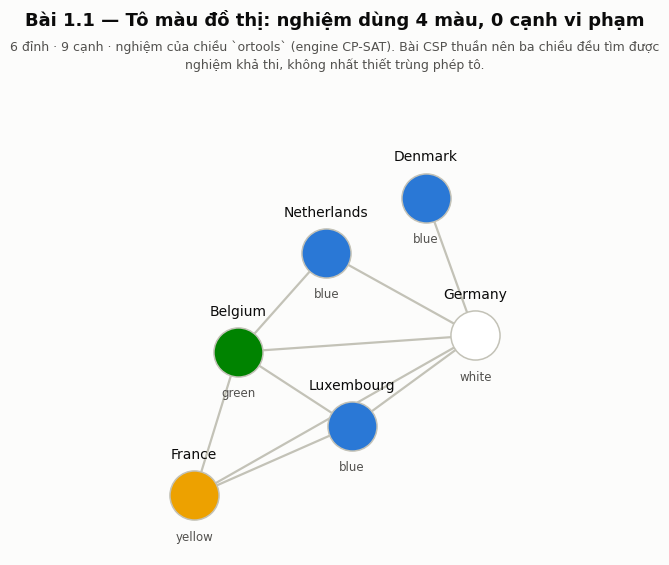

In [9]:
show_solution("1.1_graph_coloring")

## (d) Quan sát so sánh

In [10]:
show_notes("1.1_graph_coloring", "Quan sát")

## (d) Quan sát cho phần so sánh

### Kiểm chứng chéo — điều kiện tiên quyết

| | OPL | DOcplex.cp | OR-Tools |
|---|---|---|---|
| CSP: tìm được nghiệm hợp lệ | ✅ | ✅ | ✅ |
| CSP: số vi phạm cạnh (tự kiểm tra lại theo `map6.dat`) | 0 | 0 | 0 |
| CSP: số màu dùng tới | 4 | 4 | 4 |
| Mở rộng: sắc số $\chi(G)$ | **4** (Optimal) | **4** (Optimal) | **4** (OPTIMAL) |

Ba chiều **cùng kết luận khả thi**, ba nghiệm đều **hợp lệ theo đúng tập cạnh của
file dữ liệu chung** (mỗi chiều tự kiểm tra lại nghiệm của mình rồi mới in `RESULT`),
và phần mở rộng cho **cùng một giá trị tối ưu 4**, khớp với chứng minh bằng tay
$\chi(G)=\omega(G)=4$ ở mục (b).

Ba nghiệm CSP **khác nhau về nội dung** — chuyện bình thường: bài có rất nhiều
nghiệm, chiều nào về đích trước ở nghiệm nào thì báo nghiệm đó.

### Số liệu đo được

Đo trên cùng một máy, cùng file dữ liệu, mỗi cấu hình chạy **5 lần**; cột thời gian
lấy **trung vị** kèm khoảng dao động. **Số nhánh và số fails/conflicts giống hệt
nhau ở cả 5 lần chạy, cả ba chiều** — chiều OR-Tools cố định `num_search_workers=1`
và `random_seed=0`; hai chiều CP Optimizer tất định sẵn.

| Chế độ | Chiều | Engine | Obj | `solve_time_s` (trung vị) | dao động | Nhánh | Fails / Conflicts |
|---|---|---|---|---|---|---|---|
| CSP | OPL | CP Optimizer | — | 0.021 | 0.019 – 0.028 | 202 | 62 |
| CSP | DOcplex.cp | CP Optimizer | — | 0.019 | 0.019 – 0.022 | 201 | 62 |
| CSP | OR-Tools | CP-SAT | — | **0.0021** | 0.0017 – 0.0022 | **37** | **0** |
| min $\kappa$ | OPL | CP Optimizer | **4** | 0.031 | 0.024 – 0.042 | 8 373 | 4 575 |
| min $\kappa$ | DOcplex.cp | CP Optimizer | **4** | 0.029 | 0.027 – 0.041 | 8 380 | 4 594 |
| min $\kappa$ | OR-Tools | CP-SAT | **4** | **0.0027** | 0.0017 – 0.0029 | **25** | **0** |

> **Đọc bảng này cho đúng.** Bài quá nhỏ nên cột thời gian ở thang **phần trăm giây**,
> nơi nhiễu hệ thống và chi phí trích mô hình lấn át phần giải thật — dao động
> 0.019–0.028 s của một cấu hình đã rộng gần bằng khoảng cách giữa hai chiều CP
> Optimizer. Đại lượng đáng tin ở bài này là **số nhánh**: nó tất định tuyệt đối và
> phản ánh đúng công sức tìm kiếm. Bài 3.2 mới là chỗ so thời gian có ý nghĩa.
>
> Nhắc lại cảnh báo chung của dự án: `fails` (CP Optimizer) và `conflicts` (CP-SAT)
> đếm hai thứ khác nhau — chỉ so được **trong cùng một engine**, không so chéo.

### Trục NGÔN NGỮ — OPL vs DOcplex.cp (cùng engine CP Optimizer)

**Ở tầng ràng buộc, hai ngôn ngữ trùng khít.** Hai bản mẫu chính thức gần như là
bản dịch từng dòng của nhau:

```opl
Belgium != France;                 // OPL
```
```python
mdl.add(Belgium != France)         # DOcplex.cp
```

Và số liệu xác nhận: **202/62 so với 201/62** — chênh đúng **một nhánh**. Đây là
tương phản đáng giá với bài 1.2, nơi cùng hai chiều này lệch nhau **440/198 so với
255/99**. Rút ra được một kết luận cụ thể chứ không chung chung:

> Khoảng cách giữa hai ngôn ngữ **không** xuất hiện ở ràng buộc vô hướng đơn giản.
> Nó xuất hiện đúng lúc mô hình cần đưa **biểu thức** vào **ràng buộc toàn cục** —
> chỗ mà `allDifferent` của OPL chỉ nhận `dvar int[]` nên phải vật chất hoá biến
> phụ, còn `all_diff` của DOcplex.cp nhận thẳng generator biểu thức. Bài 1.1 không
> có tình huống đó, nên hai chiều đi gần như trùng nhau.

**Chênh một nhánh đó từ đâu ra? — đã truy ra tận nơi.** Xuất file `.cpo` mà
DOcplex.cp gửi cho engine, thấy thứ tự khai báo biến là

```
France = intVar(0..3);  Belgium = ...;  Germany = ...;
Netherlands = ...;      Luxembourg = ...;  Denmark = ...;
```

tức **không** phải thứ tự người viết khai báo trong Python (Belgium, Denmark,
France, …) mà là thứ tự dẫn xuất từ cây biểu thức của các ràng buộc. Thí nghiệm
kiểm chứng — chỉ **đảo hai vế của đúng một ràng buộc**, `mdl.add(Belgium != France)`
thành `mdl.add(France != Belgium)`, không đổi gì khác:

| Bản Python | Thứ tự biến trong file `.cpo` | Nhánh | Fails | Nghiệm |
|---|---|---|---|---|
| `Belgium != France` (nguyên bản IBM) | France, Belgium, … | 201 | 62 | (2,2,0,1,3,3) |
| `France != Belgium` (chỉ đảo vế) | Belgium, France, … | **202** | 62 | (3,2,2,1,0,2) |

Bản đảo vế cho **đúng 202/62 và đúng nghiệm của chiều OPL**. Ngược lại, thí nghiệm
đối chứng ở phía OPL — đảo thứ tự 6 dòng `dvar` — **không** làm đổi gì (vẫn 202/62,
vẫn nguyên nghiệm cũ).

Kết luận sạch cho trục ngôn ngữ:

> Cùng engine, cùng mô hình toán, cùng 9 ràng buộc. **OPL chuẩn hoá mô hình trước
> khi giao cho engine** nên cách người dùng sắp xếp khai báo không ảnh hưởng. Còn
> **DOcplex.cp serialize mô hình theo đúng hình dạng biểu thức Python đã dựng**, nên
> một chi tiết vô hại như đảo hai vế của `!=` cũng đổi thứ tự biến trong file `.cpo`,
> và qua đó đổi cả đường đi tìm kiếm lẫn nghiệm trả về. Thứ tự này **không nhìn thấy
> được trong mã nguồn** — phải xuất `.cpo` ra mới thấy.

**Tầng dữ liệu: OPL có, Python không.** OPL có sẵn định dạng `.dat` và cú pháp
`int NbColors = ...;` để tách dữ liệu khỏi model — nạp bằng `oplrun model.mod data.dat`.
Python không có gì tương đương: hai chiều Python phải mượn `tools/opl_dat.py`, một
trình đọc `.dat` viết riêng cho dự án, thì mới đọc chung được một file dữ liệu với
chiều OPL. Đổi lại, OPL trả giá ở chiều ngược lại — xem mục kế.

**Tầng hậu xử lý: Python có, OPL trả giá.** Khối `execute` của OPL chạy ILOG Script
(nền JavaScript) và **không thấy được các hàm của tầng model**. Hai chỗ vấp thật khi
viết bài này:

| Cần làm | Trong model OPL | Trong `execute` OPL | Trong Python |
|---|---|---|---|
| số phần tử của một tập | `card(Edges)` | ❌ `Element "card" does not exist in OPL model` → dùng `Edges.size` | `len(EDGES)` |
| lấy phần tử thứ $i$ của tập | `item(ColorNames, i)` | ❌ `Element "item" does not exist in OPL model` → phải tự đổ tập ra `new Array()` | `COLOR_NAMES[i]` |

(Cả hai lỗi trên đều là `ERROR[SCRIPT_002]` lúc chạy, không phải lỗi biên dịch — nên
chỉ lộ ra khi model đã giải xong.)

**Ngay ở tầng model, OPL cũng thiếu vài phép toán mà Python có sẵn.** Chỗ vấp thật
khi viết chốt chặn chống lệch dữ liệu: cần khẳng định "tập cạnh trong `.dat` **đúng
bằng** tập cạnh hardcode".

```opl
assert Edges == HardcodedEdges;   // ❌ ERROR[GENERATE_002]:
                                  //    Operator not available for {Edge} == {Edge}
assert card(Edges inter HardcodedEdges) == card(HardcodedEdges)   // ✅ phải viết vòng
    && card(Edges) == card(HardcodedEdges);
```
```python
assert _HARDCODED_EDGES == {tuple(e) for e in EDGES}    # ✅ Python có sẵn == cho set
```

**Đổi lại, tầng dữ liệu của OPL kiểm tra chặt hơn Python.** `oplrun` từ chối chạy nếu
file `.dat` gán một phần tử mà model **không khai báo** — `ERROR[GENERATE_200]:
Element "NbColors" not defined`. Nghĩa là model và dữ liệu phải khớp nhau **hai
chiều**. Bên Python, `opl_dat.load()` chỉ trả về một `dict`; khoá thừa không ai kêu,
khoá thiếu thì tới lúc dùng mới nổ `KeyError`.

Nói cách khác, OPL là **hai ngôn ngữ trong một file** (ngôn ngữ mô hình + ngôn ngữ
script), và ranh giới giữa chúng là thứ phải học thuộc. DOcplex.cp chỉ có một ngôn
ngữ: dựng mô hình, đọc dữ liệu, kiểm tra nghiệm, in báo cáo — tất cả đều là Python.

**Một thứ OPL có mà Python phải tự làm: `assert` ở tầng model.** OPL cho viết
`assert card(Edges) == 9;` ngay trong model, và oplrun bắt lỗi ở giai đoạn *trích
mô hình* với mã lỗi riêng `ERROR[GENERATE_100]` trước khi engine chạy. Python dùng
`assert` của chính ngôn ngữ — cùng hiệu quả, nhưng đó là kiểm tra của chương trình
chứ không phải của công cụ mô hình hoá.

### Trục ENGINE — DOcplex.cp vs OR-Tools (cùng ngôn ngữ Python)

**Cú pháp gần như không phân biệt được.** Đặt cạnh nhau, hai thư viện khác nhau ở
tên hàm chứ không ở cách nghĩ:

```python
mdl   = CpoModel();       x = mdl.integer_var(0, 3, name)   ; mdl.add(x != y)     # docplex.cp
model = cp_model.CpModel(); x = model.new_int_var(0, 3, name); model.add(x != y)  # ortools
```

Khác biệt nằm **bên dưới**, và ở bài này nó lộ ra rất rõ:

| | CP Optimizer | CP-SAT | tỉ lệ |
|---|---|---|---|
| CSP — nhánh | 201 | **37** | 5.4× ít hơn |
| CSP — thời gian (trung vị) | 0.019 s | **0.0021 s** | ≈9× nhanh hơn |
| min $\kappa$ — nhánh | 8 380 | **25** | **335× ít hơn** |
| min $\kappa$ — thời gian (trung vị) | 0.029 s | **0.0027 s** | ≈11× nhanh hơn |
| đại lượng "thất bại" | 4 594 fails | **0** conflicts | — |

**Con số 0 conflict là điểm đáng nói nhất.** CP-SAT không hề vào tìm kiếm thật:
tầng *presolve* của nó rút gọn mô hình tới mức chứng minh xong tối ưu. CP Optimizer
đi lối ngược lại — duyệt cây tìm kiếm và **nâng dần chặn dưới bằng cách vét cạn**;
log của nó cho thấy đúng quá trình đó:

```
+ New bound is 3
*             4        7  0.03s        1      (gap is 25.00%)
+ New bound is 4 (gap is 0.00%)
```

Nó tìm ra nghiệm 4 màu rất sớm (7 nhánh), rồi tiêu **hơn 8 000 nhánh còn lại chỉ để
chứng minh 3 màu là không thể**. Trong khi đó chặn dưới $\chi\ge\omega=4$ là hiển
nhiên với con người khi nhìn thấy $K_4$ — nhưng CP Optimizer không suy luận theo
clique, nó phải vét. CP-SAT thì sinh mệnh đề và rút gọn ở presolve nên bắt được
ngay.

**Nhưng đừng vội kết luận "CP-SAT mạnh hơn".** Cùng phép so này ở bài 3.2, thứ tự
đảo ngược: trên bộ `large`, CP Optimizer về đích ở **0.67 s** còn CP-SAT mất
**2.52 s**. Kết luận đúng là *hai chiến lược khác nhau*:

- **CP-SAT** — ít nhánh, mỗi nhánh đắt; mạnh ở bài tổ hợp thuần và ở việc chứng
  minh tối ưu, nhờ học mệnh đề xung đột và presolve rất khoẻ.
- **CP Optimizer** — nhiều nhánh, mỗi nhánh cực rẻ; mạnh ở bài lập lịch, nơi nó có
  hơn 20 năm tối ưu riêng cho biến interval.

Bài 1.1 là bài tổ hợp thuần cỡ tí hon — đúng sân của CP-SAT. Bài 3.2 là bài lập
lịch cỡ lớn — đúng sân của CP Optimizer.

**Tính tái lập.** CP-SAT chạy đa luồng nên số liệu đổi giữa các lần chạy (bài 1.2 đã
ghi nhận `branches` lúc 475 lúc 0). Chiều OR-Tools của bài này vì thế cố định
`num_search_workers=1` và `random_seed=0`; năm lần chạy cho đúng 37 nhánh cả năm lần.
Hai chiều CP Optimizer tất định sẵn, không cần can thiệp.

### Ghi chú về mô hình còn siết được

Cả ba chiều đều dùng (C1) — 9 ràng buộc $\neq$ rời rạc — vì phải giữ nguyên văn hai
ví dụ chính thức. Nếu được viết lại tự do, cách siết là (C1′): phủ 9 cạnh bằng các
clique rồi đặt `allDifferent` lên mỗi clique. Ở đồ thị này, $K_4=\{$BE, FR, DE, LU$\}$
đã nuốt 6 trong 9 cạnh, còn lại 3 cạnh DK–DE, BE–NL, DE–NL. Với 6 đỉnh thì không bõ,
nhưng đây đúng là cách thu hẹp cây tìm kiếm khi đồ thị lớn lên — và nó lý giải vì sao
CP Optimizer phải vét 8 000 nhánh cho phần min sắc số: **thông tin clique có sẵn
trong dữ liệu, nhưng mô hình không nói cho engine biết.**

---

---

# Bài 1.2 — N-Queens

## (a) Phát biểu bài toán

In [11]:
show_notes("1.2_nqueens", "Phát biểu")

## (a) Phát biểu bài toán

Cho bàn cờ vuông $N \times N$. Đặt $N$ quân hậu lên bàn cờ sao cho không hai quân
nào ăn được nhau. Quân hậu trong cờ vua ăn theo hàng ngang, cột dọc và cả hai
đường chéo — nên điều kiện là: không hai quân nào cùng hàng, cùng cột, hoặc cùng
một đường chéo.

**Dữ liệu vào:** một số nguyên $N \ge 1$.
**Dữ liệu ra:** vị trí của $N$ quân hậu, hoặc kết luận không tồn tại lời giải
(xảy ra đúng với $N = 2$ và $N = 3$).

Đây là bài **CSP thuần** — chỉ tìm một cấu hình khả thi, không có hàm mục tiêu.
Bài toán thuộc lớp *Assignment / Labeling* trong bản đồ phân loại CP: gán giá trị
rời rạc cho các biến, ràng buộc chủ đạo là ràng buộc phân biệt.

## (b) Mô hình toán học

Mô hình dưới đây là **hợp đồng chung** mà cả ba chiều cùng cài đặt. Ba đoạn code ở mục (c) chỉ là ba cách diễn đạt đúng mô hình này.

In [12]:
show_notes("1.2_nqueens", "Mô hình toán")

## (b) Mô hình toán học — dùng chung cho cả ba chiều

### Tập hợp và tham số

| Ký hiệu | Ý nghĩa |
|---|---|
| $N$ | kích thước bàn cờ |
| $\mathcal{N} = \{0, 1, \dots, N-1\}$ | tập chỉ số, dùng chung cho hàng và cột |

### Biến quyết định

| Biến | Miền | Ý nghĩa |
|---|---|---|
| $q_i$ | $\mathcal{N}$ | cột đặt quân hậu của hàng $i$, với $i \in \mathcal{N}$ |

**Chỉ $N$ biến, mỗi biến $N$ giá trị.** Cách mã hoá này là quyết định quan trọng
nhất của bài: vì mỗi hàng $i$ có đúng một biến $q_i$, ràng buộc "không hai hậu
cùng hàng" **tự động thoả** và không cần viết ra. Cách mã hoá ngây thơ dùng
$N^2$ biến nhị phân $x_{i,j}$ (có hậu ở ô $(i,j)$ hay không) sẽ phải viết thêm
ràng buộc hàng, và cho không gian tìm kiếm lớn hơn hẳn.

### Biểu thức dẫn xuất — chỉ số đường chéo

Hai quân hậu ở $(i, q_i)$ và $(j, q_j)$ nằm trên cùng một đường chéo khi nào?

- Đường chéo hướng $\nearrow$ (từ dưới-trái lên trên-phải) gồm các ô có **tổng**
  hàng và cột không đổi. Vậy hai hậu cùng đường chéo này $\iff i + q_i = j + q_j$.
- Đường chéo hướng $\searrow$ gồm các ô có **hiệu** không đổi. Vậy hai hậu cùng
  đường chéo này $\iff q_i - i = q_j - j$.

Đặt hai họ biểu thức dẫn xuất:

$$d^{\nearrow}_i = q_i + i \in \{0, \dots, 2(N-1)\}, \qquad
  d^{\searrow}_i = q_i - i \in \{-(N-1), \dots, N-1\}$$

### Ràng buộc

$$\texttt{allDifferent}\bigl(q_0, q_1, \dots, q_{N-1}\bigr) \tag{C1}$$

$$\texttt{allDifferent}\bigl(d^{\nearrow}_0, d^{\nearrow}_1, \dots, d^{\nearrow}_{N-1}\bigr) \tag{C2}$$

$$\texttt{allDifferent}\bigl(d^{\searrow}_0, d^{\searrow}_1, \dots, d^{\searrow}_{N-1}\bigr) \tag{C3}$$

(C1) không hai hậu cùng cột · (C2) không hai hậu cùng đường chéo $\nearrow$ ·
(C3) không hai hậu cùng đường chéo $\searrow$.

### Hàm mục tiêu

Không có. Bài toán là CSP thuần:

$$\text{tìm } q \in \mathcal{N}^{N} \text{ thoả (C1), (C2), (C3)}$$

### Vì sao dùng `allDifferent` chứ không phải các bất đẳng thức đôi một

Ba ràng buộc trên tương đương về mặt **tập nghiệm** với dạng viết đôi một:

$$q_i \ne q_j, \quad q_i + i \ne q_j + j, \quad q_i - i \ne q_j - j
\qquad \forall\, i < j \in \mathcal{N}$$

Nhưng chúng **không** tương đương về mặt **lan truyền ràng buộc**, và đây là điểm
cốt lõi của Constraint Programming:

| | Số ràng buộc | Mức lọc miền đạt được |
|---|---|---|
| đôi một $\ne$ | $3\binom{N}{2} = O(N^2)$ | chỉ loại được giá trị khi một biến đã cố định |
| `allDifferent` | 3 | **domain consistency** — thuật toán Régin dựa trên ghép cặp cực đại trên đồ thị hai phía, loại được mọi giá trị không thuộc bất kỳ ghép cặp hoàn hảo nào |

Ví dụ: nếu ba biến $q_1, q_2, q_3$ cùng còn miền $\{4, 5\}$, `allDifferent` phát
hiện ngay mâu thuẫn (ba biến không thể nhận hai giá trị phân biệt) trong khi các
bất đẳng thức đôi một không thấy gì cho tới khi phải gán thử. Đây chính là giá trị
của **ràng buộc toàn cục** (global constraint) — thứ phân biệt CP với cách mô hình
hoá bằng quy hoạch tuyến tính nguyên.

## (c) Cài đặt ba chiều

### OPL → engine CP Optimizer

In [13]:
show_dimension_code("1.2_nqueens", "opl")

**OPL → engine CP Optimizer · ✍️ viết mới**

```opl
/* Bài 1.2 — N-Queens | Chiều OPL (engine CP Optimizer)
 * Nguồn: VIẾT MỚI. IBM không phát hành ví dụ N-Queens bằng OPL trong bộ
 * examples đi kèm CPLEX Studio 22.2 (xem NOTES.md).
 *
 * Chạy:  tools/oplrun.sh models/1.2_nqueens/opl/nqueens.mod data/queens/nqueens.dat
 *
 * GHI CHÚ NGÔN NGỮ (điểm so sánh với DOcplex.cp):
 *   OPL không cho truyền mảng biểu thức vào allDifferent — `allDifferent(dexpr int[])`
 *   bị từ chối với lỗi "not available in context CP". Vì vậy hai đường chéo phải
 *   được vật chất hoá thành dvar phụ rồi ràng buộc bằng ==. Bản DOcplex.cp cùng
 *   engine viết thẳng all_diff([q[i] + i for i in ...]) — đây là khác biệt thuần
 *   NGÔN NGỮ, không phải khác biệt engine.
 */

using CP;

int n = ...;
range R = 0..n-1;

// q[i] = cột đặt hậu ở hàng i. Mã hoá này đã ngầm loại hết xung đột theo hàng.
dvar int q[R] in R;

// Hai mảng phụ cho đường chéo. Xem ghi chú ngôn ngữ ở trên.
dvar int diagUp[R]   in 0..2*(n-1);
dvar int diagDown[R] in -(n-1)..(n-1);

subject to {
  forall (i in R) diagUp[i]   == q[i] + i;
  forall (i in R) diagDown[i] == q[i] - i;

  allDifferent(q);         // không hai hậu cùng cột
  allDifferent(diagUp);    // không hai hậu cùng đường chéo ↗
  allDifferent(diagDown);  // không hai hậu cùng đường chéo ↘
}

execute {
  var cols = "[";
  for (var i in R) cols += (i > 0 ? "," : "") + q[i];
  cols += "]";
  writeln("QUEENS ", cols);
  writeln("RESULT {\"status\":\"Feasible\""
        + ",\"solve_time_s\":" + cp.info.solveTime
        + ",\"branches\":" + cp.info.numberOfBranches
        + ",\"fails\":" + cp.info.numberOfFails
        + ",\"n\":" + n + "}");
}
```

### DOcplex.cp → engine CP Optimizer

In [14]:
show_dimension_code("1.2_nqueens", "docplexcp")

**Python (docplex.cp) → engine CP Optimizer · ✅ mẫu chính thức**

```python
"""Bài 1.2 — N-Queens | Chiều DOcplex.cp (engine CP Optimizer)

Nguồn: LẤY MẪU CHÍNH THỨC.
  IBMDecisionOptimization/docplex — examples/cp/basic/n_queen.py
  (c) Copyright IBM Corp. 2015, 2022 — Apache License 2.0

Phần DỰNG MÔ HÌNH giữ nguyên như bản gốc của IBM. Chỉ bổ sung: cấu hình engine
cục bộ, tham số n qua dòng lệnh, và dòng RESULT theo giao kèo của tools/runner.py.

Chạy:  python3 models/1.2_nqueens/docplexcp/nqueens_cp.py [n]

GHI CHÚ NGÔN NGỮ (điểm so sánh với OPL):
  all_diff() nhận thẳng generator các BIỂU THỨC `x[i] + i`. Bản OPL cùng engine
  phải khai báo mảng dvar phụ rồi buộc bằng == vì allDifferent của OPL chỉ nhận
  mảng biến. Cùng engine CP Optimizer, cùng mô hình toán — khác biệt ở đây là
  thuần NGÔN NGỮ.
"""

import json
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path(__file__).resolve().parents[3] / "tools"))
import cpo_env  # noqa: F401  — trỏ docplex.cp sang cpoptimizer cục bộ

from docplex.cp.model import CpoModel

NB_QUEEN = int(sys.argv[1]) if len(sys.argv) > 1 else 8

# --- dựng mô hình: nguyên văn ví dụ chính thức của IBM -----------------------
mdl = CpoModel()

# Cột của từng hậu; chỉ số mảng là hàng nên ràng buộc theo hàng đã tự thoả.
x = mdl.integer_var_list(NB_QUEEN, 0, NB_QUEEN - 1, "X")

mdl.add(mdl.all_diff(x))                                        # khác cột
mdl.add(mdl.all_diff(x[i] + i for i in range(NB_QUEEN)))        # khác đường chéo ↗
mdl.add(mdl.all_diff(x[i] - i for i in range(NB_QUEEN)))        # khác đường chéo ↘
# --- hết phần nguyên văn ----------------------------------------------------

msol = mdl.solve(TimeLimit=60, LogVerbosity="Quiet")

if msol:
    print("QUEENS", [msol[v] for v in x])
    for row in range(NB_QUEEN):
        qx = msol[x[row]]
        print(" ".join("Q" if c == qx else "." for c in range(NB_QUEEN)))

infos = msol.get_solver_infos() if msol else {}
print("RESULT " + json.dumps({
    "status": str(msol.get_solve_status()) if msol else "NoSolution",
    "solve_time_s": round(msol.get_solve_time(), 4) if msol else None,
    "branches": infos.get("NumberOfBranches"),
    "fails": infos.get("NumberOfFails"),
    "n": NB_QUEEN,
}))
```

### OR-Tools → engine CP-SAT

In [15]:
show_dimension_code("1.2_nqueens", "ortools")

**Python (ortools.sat) → engine CP-SAT · ✅ mẫu chính thức**

```python
"""Bài 1.2 — N-Queens | Chiều OR-Tools (engine CP-SAT)

Nguồn: LẤY MẪU CHÍNH THỨC.
  https://developers.google.com/optimization/cp/queens

Phần dựng mô hình theo đúng ví dụ chính thức của Google; bổ sung tham số n qua
dòng lệnh và dòng RESULT theo giao kèo của tools/runner.py.

Chạy:  python3 models/1.2_nqueens/ortools/nqueens_sat.py [n]

GHI CHÚ ENGINE (điểm so sánh với DOcplex.cp — cùng Python, khác engine):
  Cú pháp gần như trùng khít bản DOcplex.cp: AddAllDifferent cũng nhận generator
  biểu thức. Khác biệt nằm ở BÊN DƯỚI: CP-SAT dịch toàn bộ mô hình xuống mệnh đề
  SAT + lazy clause generation, nên báo số CONFLICTS (xung đột học được) thay vì
  FAILS (nhánh chết) như CP Optimizer. Hai con số này KHÔNG so sánh trực tiếp
  được với nhau — chúng đếm hai thứ khác nhau.

  CP-SAT chạy đa luồng nên số liệu đổi giữa các lần chạy; ở đây cố định
  num_search_workers=1 và random_seed=0 để con số trong NOTES.md tái lập được.
"""

import json
import sys

from ortools.sat.python import cp_model

BOARD_SIZE = int(sys.argv[1]) if len(sys.argv) > 1 else 8

model = cp_model.CpModel()

# queens[i] = cột của hậu ở hàng i.
queens = [model.new_int_var(0, BOARD_SIZE - 1, f"x_{i}") for i in range(BOARD_SIZE)]

model.add_all_different(queens)                                          # khác cột
model.add_all_different(queens[i] + i for i in range(BOARD_SIZE))        # khác đường chéo ↗
model.add_all_different(queens[i] - i for i in range(BOARD_SIZE))        # khác đường chéo ↘

solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 60.0
solver.parameters.num_search_workers = 1   # tái lập được số liệu (xem docstring)
solver.parameters.random_seed = 0
status = solver.solve(model)

if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    cols = [solver.value(q) for q in queens]
    print("QUEENS", cols)
    for row in range(BOARD_SIZE):
        print(" ".join("Q" if c == cols[row] else "." for c in range(BOARD_SIZE)))

    # Cấu trúc nghiệm cho phần vẽ hình (giao kèo SOLUTION của tools/runner.py).
    # `queens[i]` = cột của hậu ở hàng i — đủ để dựng lại cả bàn cờ.
    print("SOLUTION " + json.dumps({
        "problem": "nqueens",
        "n": BOARD_SIZE,
        "queens": cols,
    }))

print("RESULT " + json.dumps({
    "status": solver.status_name(status),
    "solve_time_s": round(solver.wall_time, 4),
    "branches": solver.num_branches,
    # CP-SAT không có khái niệm "fails"; conflicts là đại lượng gần nhất.
    "fails": solver.num_conflicts,
    "n": BOARD_SIZE,
}))
```

## Chạy — cả ba chiều, cùng một bộ dữ liệu

Bảng dưới sinh ra bằng cách **chạy thật** ba file code vừa in ở trên.

In [16]:
run_table("1.2_nqueens")

chiều,ngôn ngữ,engine,nguồn,trạng thái,mục tiêu,thời gian giải (s),nhánh,fails/conflicts
opl,OPL,CP Optimizer,✍️,Feasible,—,0.022,440,198
docplexcp,Python (docplex.cp),CP Optimizer,✅,Feasible,—,0.02,255,99
ortools,Python (ortools.sat),CP-SAT,✅,OPTIMAL,—,0.0055,475,9


### Kiểm chứng chéo

Ba chiều phải cùng ra một nghiệm tối ưu. Không có bước này thì mọi so sánh hiệu năng đều vô nghĩa — nhanh hơn mà giải sai bài thì không nói lên điều gì.

In [17]:
cross_check("1.2_nqueens")

**Kiểm chứng chéo — bài 1.2_nqueens**

CSP thuần, không có hàm mục tiêu

`opl` → Feasible · `docplexcp` → Feasible · `ortools` → OPTIMAL → ✅ cả ba đều tìm được nghiệm khả thi

> Không có giá trị mục tiêu để đối chiếu, nên phép kiểm ở đây chỉ xác nhận **cả ba đều tìm được nghiệm**. Tính hợp lệ của từng nghiệm do chính model tự kiểm lại theo dữ liệu gốc rồi báo qua `status`; nghiệm sai thành `Invalid` và bị `runner.py` tính là FAIL.


### Nghiệm tìm được

Hình dưới là **nghiệm của chiều `ortools`** (engine CP-SAT) — chiều duy nhất chạy được mà không cần giấy phép IBM, nên hình này dựng được trên mọi máy. Ba chiều vừa được kiểm chứng chéo ở ô ngay trên: cả ba **cùng chạy trên một bộ dữ liệu và cùng tìm được nghiệm hợp lệ**. Đây là bài CSP thuần, không có hàm mục tiêu, nên phép kiểm xác nhận ba nghiệm cùng hợp lệ chứ không xác nhận ba nghiệm trùng khít nhau.

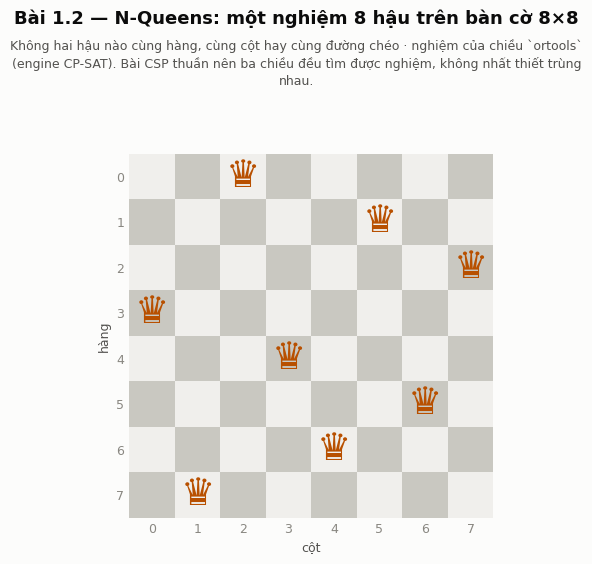

In [18]:
show_solution("1.2_nqueens")

## (d) Quan sát so sánh

In [19]:
show_notes("1.2_nqueens", "Quan sát")

## (d) Quan sát cho phần so sánh

### Trục NGÔN NGỮ — OPL vs DOcplex.cp (cùng engine CP Optimizer)

DOcplex.cp truyền thẳng mảng **biểu thức** vào ràng buộc, đúng như mô hình toán viết:

```python
mdl.add(mdl.all_diff(x[i] + i for i in range(NB_QUEEN)))
```

OPL không cho phép. `allDifferent(dexpr int[])` bị từ chối với thông báo
*"Function allDifferent(dexpr int[R]) not available in context CP"*. Hai họ
$d^{\nearrow}, d^{\searrow}$ phải được **vật chất hoá** thành mảng `dvar` phụ rồi
buộc bằng `==`:

```opl
dvar int diagUp[R] in 0..2*(n-1);
forall (i in R) diagUp[i] == q[i] + i;
allDifferent(diagUp);
```

Hệ quả đo được, cùng engine, $N = 8$:

| Chiều | Biến | Ràng buộc | log₂ không gian tìm kiếm | Nhánh | Fails |
|---|---|---|---|---|---|
| OPL | **24** | **21** | 24.0 | **440** | **198** |
| DOcplex.cp | **8** | **3** | 24.0 | **255** | **99** |

Đọc bảng này cho đúng — chỗ này dễ kết luận sai:

- **Không gian tìm kiếm y hệt nhau (24.0 = $8\log_2 8$).** Presolve của CP Optimizer
  nhận ra 16 biến phụ là **hàm xác định** của $q$ nên chúng không thêm một bậc tự
  do nào. Nói cách khác, hai mô hình mô tả đúng cùng một bài toán, không mô hình
  nào "to hơn".
- **Nhưng số nhánh lệch gần gấp đôi.** Nguyên nhân không phải kích thước không gian
  mà là **heuristic phân nhánh nhìn thấy 24 biến thay vì 8**, nên có thể chọn phân
  nhánh trên biến phụ — một quyết định gần như vô ích vì biến phụ sẽ tự cố định khi
  $q$ cố định. Cộng thêm 18 ràng buộc `==` phải lan truyền ở mỗi nút.

Đây là dẫn chứng sạch cho luận điểm trung tâm của báo cáo: **giới hạn của ngôn ngữ
mô hình hoá ép người viết dùng một cách diễn đạt kém hơn, và cái giá phải trả đo
được ngay cả khi engine không đổi.** Không có chiều DOcplex.cp thì không tách được
điều này khỏi ảnh hưởng của engine.

### Trục ENGINE — DOcplex.cp vs OR-Tools (cùng Python, cùng mô hình)

Cú pháp gần như trùng khít — cả hai đều nhận generator biểu thức:

| DOcplex.cp | OR-Tools |
|---|---|
| `mdl.all_diff(x)` | `model.add_all_different(x)` |
| `mdl.all_diff(x[i] + i for i in ...)` | `model.add_all_different(q[i] + i for i in ...)` |

Khác biệt nằm bên dưới:

- CP Optimizer báo **fails** — số nhánh chết trong cây tìm kiếm.
- CP-SAT báo **conflicts** — số mệnh đề xung đột học được, vì nó dịch mô hình xuống
  SAT rồi dùng lazy clause generation.

Hai đại lượng này **không so trực tiếp với nhau được**; chỉ so được trong cùng một
engine.

Thêm nữa, CP-SAT chạy đa luồng nên số liệu **đổi giữa các lần chạy** — cùng model
$N = 8$ đã ghi nhận `branches` lúc 475, lúc 0 (presolve giải xong trước khi vào tìm
kiếm). Vì thế bản trong repo cố định `num_search_workers = 1` và `random_seed = 0`;
sau khi cố định, ba lần chạy liên tiếp cho đúng một bộ số:

| Chiều | Nhánh | Fails / Conflicts |
|---|---|---|
| DOcplex.cp (CP Optimizer) | **255** | **99** (fails) |
| OR-Tools (CP-SAT) | **475** | **9** (conflicts) |

Con số 475 nhánh so với 9 conflict cho thấy rõ hai engine đếm hai thứ khác nhau:
CP-SAT duyệt nhiều nhánh nhưng chỉ học được 9 mệnh đề xung đột, trong khi CP
Optimizer báo 99 nhánh chết trên 255 nhánh.

### Giới hạn Community Edition

Không gian tìm kiếm của bài này là $N^N$, tức $\log_2 = N\log_2 N$. Trần 2^1000 của
Community Edition cho $N \lesssim 140$. Đã kiểm chứng: $N = 8$ chạy bình thường,
$N = 200$ ($\approx 2^{1529}$) bị engine từ chối với
`FATAL[ENGINE_001]: Problem size limit exceeded`.